# K-Means Clustering — Steam Games (3 Clusters)

This notebook runs K-Means with **3 clusters** on the preprocessed Steam games dataset and outputs a separate CSV for each cluster.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print('Libraries imported.')

Libraries imported.


## 1. Load & Preprocess Data

In [11]:
from configs.config import RAW_MERGED_PATH
from src.data.loader import load_merged, validate_merged
from src.data.preprocessor import run_preprocessing_pipeline
from src.features.engineer import prepare_features

df_raw = load_merged(RAW_MERGED_PATH, verbose=False)
validate_merged(df_raw)
df = run_preprocessing_pipeline(df_raw, post_release=False, verbose=False)
data = prepare_features(df, post_release=False, return_pipeline=True)

X = data['X_train']
feature_cols = data['output_cols']

# Keep the raw dataframe aligned with the train split for labelling
X_raw = data['X_train_raw'].reset_index(drop=True)

print(f'Feature matrix: {X.shape[0]:,} samples  x  {X.shape[1]} features')

copiesSold has 98 null values — check the merge.


Feature matrix: 80,633 samples  x  79 features


## 2. Filter to RFECV-Selected Features (optional)

If you have `rfecv_selected_ranking.csv`, uncomment the block below to restrict clustering to the 71 selected features.

In [18]:
import os
rfecv_path = 'rfecv_selected_ranking.csv'

if os.path.exists(rfecv_path):
    rfecv_df = pd.read_csv(rfecv_path)
    selected = rfecv_df[rfecv_df['selected'] == True]['feature'].tolist()
    selected_idx = [i for i, c in enumerate(feature_cols) if c in selected]
    X = X[:, selected_idx]
    feature_cols = [feature_cols[i] for i in selected_idx]
    print(f'Using {len(feature_cols)} RFECV-selected features.')
else:
    print(f'No RFECV file found — using all {X.shape[1]} features.')

Using 60 RFECV-selected features.


## 3. Fit K-Means (k=3)

In [26]:
N_CLUSTERS = 3

# Scale features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10,
)
labels = kmeans.fit_predict(X_scaled)

print(f'K-Means fitted  |  Inertia: {kmeans.inertia_:,.0f}\n')
for i in range(N_CLUSTERS):
    n = (labels == i).sum()
    print(f'  Cluster {i}: {n:>7,} games  ({100*n/len(labels):.1f}%)')

K-Means fitted  |  Inertia: 4,364,502

  Cluster 0:   7,618 games  (9.4%)
  Cluster 1:  38,243 games  (47.4%)
  Cluster 2:  34,772 games  (43.1%)


## 4. Cluster Profiles — Sales & Key Features

In [27]:
# Attach cluster label to the raw training slice
X_raw['cluster'] = labels

# Pull copiesSold from the processed df aligned to train indices
train_idx = data['X_train_raw'].index
X_raw['copiesSold'] = df.loc[train_idx, 'copiesSold'].values

profile_rows = []
for i in range(N_CLUSTERS):
    sub = X_raw[X_raw['cluster'] == i]
    sales = sub['copiesSold']
    row = {
        'Cluster': i,
        'N_Games': len(sub),
        'Pct': f"{100*len(sub)/len(X_raw):.1f}%",
        'Mean_Sales': round(sales.mean()),
        'Median_Sales': round(sales.median()),
        'Max_Sales': round(sales.max()),
    }
    # Add means of interpretable columns if available
    for col in ['Price', 'publisher_class_ord', 'has_multiplayer',
                'is_free_to_play', 'tag_count', 'DLC count']:
        if col in sub.columns:
            row[f'avg_{col}'] = round(sub[col].mean(), 3)
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows).set_index('Cluster')
display(profile_df)

,N_Games,Pct,Mean_Sales,Median_Sales,Max_Sales,avg_Price,avg_publisher_class_ord,avg_has_multiplayer,avg_is_free_to_play,avg_tag_count,avg_DLC count
Cluster,,,,,,,,,,,
0,7618,9.4%,44534,357,29844628,1.816,0.318,0.330,0.151,10.383,0.079
1,38243,47.4%,129343,893,343456914,1.850,0.635,0.190,0.053,16.855,0.231
2,34772,43.1%,17654,433,18542408,1.314,0.376,0.132,0.252,2.584,0.096


## 5. Visualise Clusters (PCA 2D)

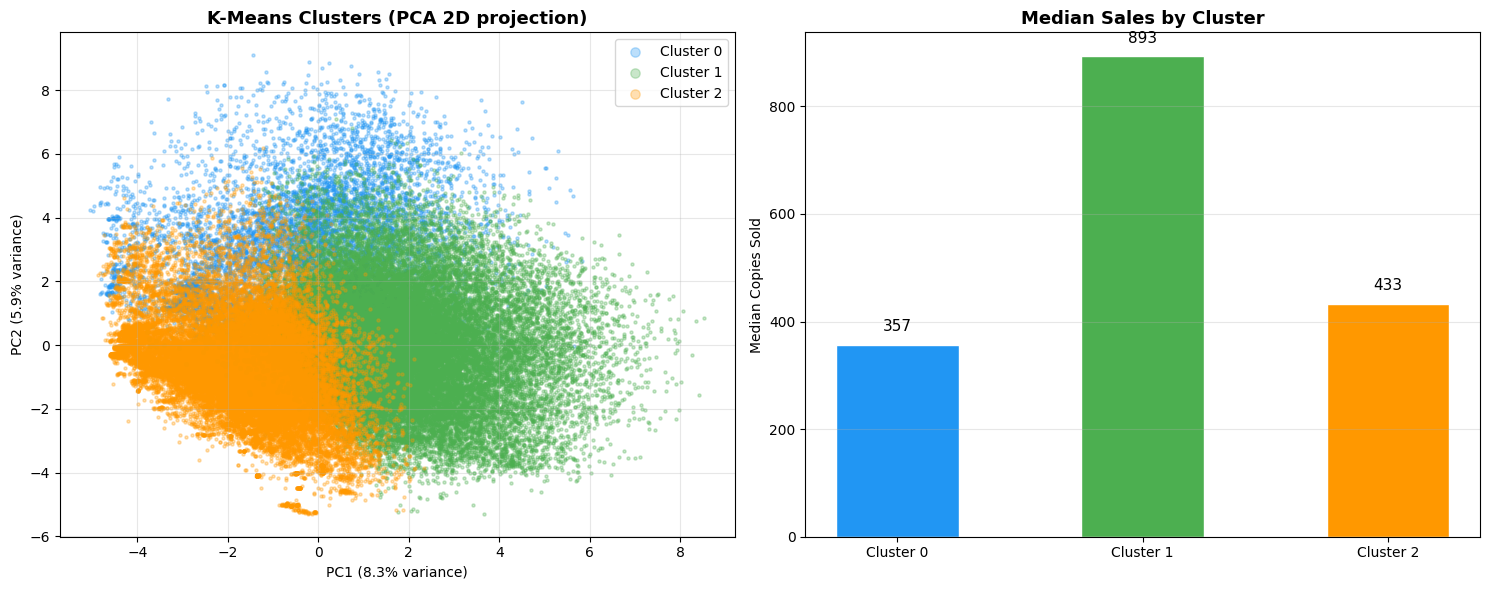

PCA explained variance: 14.3% total


In [28]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

colors = ['#2196F3', '#4CAF50', '#FF9800']
cluster_names = [f'Cluster {i}' for i in range(N_CLUSTERS)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- PCA scatter ---
ax = axes[0]
for i in range(N_CLUSTERS):
    mask = labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[i], label=cluster_names[i],
               alpha=0.3, s=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('K-Means Clusters (PCA 2D projection)', fontsize=13, fontweight='bold')
ax.legend(markerscale=3, fontsize=10)
ax.grid(True, alpha=0.3)

# --- Median sales by cluster ---
ax2 = axes[1]
medians = [X_raw[X_raw['cluster'] == i]['copiesSold'].median() for i in range(N_CLUSTERS)]
bars = ax2.bar(cluster_names, medians, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, medians):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{int(val):,}', ha='center', va='bottom', fontsize=11)
ax2.set_ylabel('Median Copies Sold')
ax2.set_title('Median Sales by Cluster', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% total')

## 6. Sales Distribution by Cluster

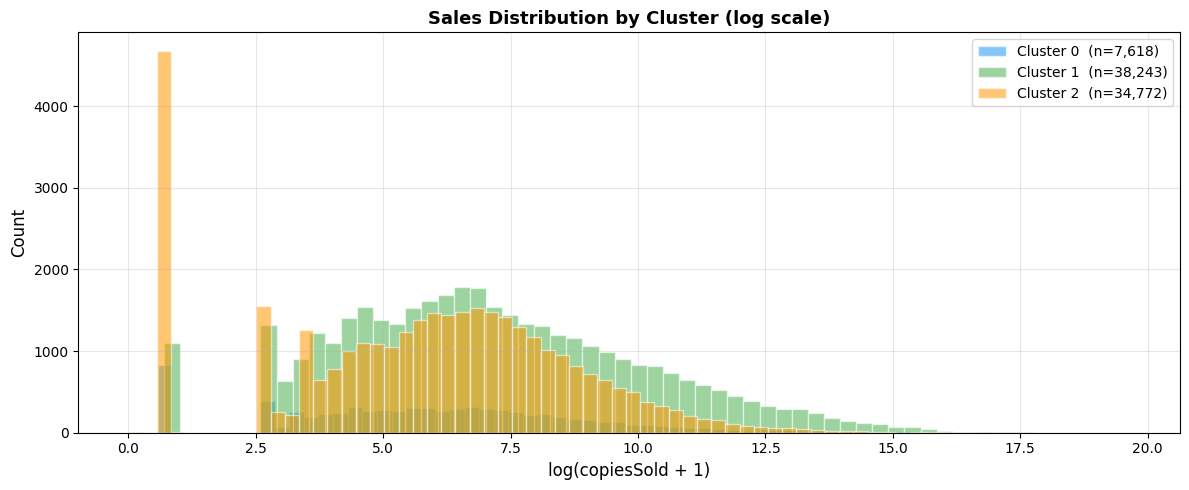

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
for i in range(N_CLUSTERS):
    sales = X_raw[X_raw['cluster'] == i]['copiesSold']
    log_sales = np.log1p(sales)
    ax.hist(log_sales, bins=60, alpha=0.55, color=colors[i],
            label=f'Cluster {i}  (n={len(sales):,})', edgecolor='white')

ax.set_xlabel('log(copiesSold + 1)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Sales Distribution by Cluster (log scale)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Export — One CSV Per Cluster

In [30]:
import os
os.makedirs('cluster_outputs', exist_ok=True)

# Attach cluster label to the full feature dataframe
full_cluster_df = X_raw.copy()

# Also save the combined file
combined_path = 'cluster_outputs/all_clusters.csv'
full_cluster_df.to_csv(combined_path, index=False)
print(f'Combined dataset saved → {combined_path}  ({len(full_cluster_df):,} rows)')
print()

# Save one CSV per cluster
for i in range(N_CLUSTERS):
    cluster_data = full_cluster_df[full_cluster_df['cluster'] == i].drop(columns=['cluster'])
    path = f'cluster_outputs/cluster_{i}.csv'
    cluster_data.to_csv(path, index=False)
    print(f'Cluster {i} → {path}  ({len(cluster_data):,} games,  median sales: {cluster_data["copiesSold"].median():,.0f})')

print('\nAll cluster CSV files saved to cluster_outputs/')

Combined dataset saved → cluster_outputs/all_clusters.csv  (80,633 rows)

Cluster 0 → cluster_outputs/cluster_0.csv  (7,618 games,  median sales: 357)
Cluster 1 → cluster_outputs/cluster_1.csv  (38,243 games,  median sales: 893)
Cluster 2 → cluster_outputs/cluster_2.csv  (34,772 games,  median sales: 433)

All cluster CSV files saved to cluster_outputs/


## 8. Preview Each Cluster Dataset

In [32]:
for i in range(N_CLUSTERS):
    cluster_data = pd.read_csv(f'cluster_outputs/cluster_{i}.csv')
    print(f'\n{"="*60}')
    print(f'CLUSTER {i}  —  {len(cluster_data):,} games')
    print(f'{"="*60}')
    display(cluster_data.describe().T[['mean', 'std', 'min', '50%', 'max']]
            .rename(columns={'50%': 'median'})
            .round(2)
            .head(10))


CLUSTER 0  —  7,618 games


,mean,std,min,median,max
Required age,0.05,0.92,0.0,0.00,18.00
Price,1.82,1.00,0.0,1.94,5.30
Discount,1.35,8.31,0.0,0.00,91.00
DLC count,0.08,0.30,0.0,0.00,4.19
Windows,1.00,0.02,0.0,1.00,1.00
Mac,0.13,0.34,0.0,0.00,1.00
Linux,0.11,0.31,0.0,0.00,1.00
Achievements,1.11,1.50,0.0,0.00,8.32
earlyAccess,0.99,0.10,0.0,1.00,1.00
release_year,2022.13,2.87,2013.0,2023.00,2026.00



CLUSTER 1  —  38,243 games


,mean,std,min,median,max
Required age,0.27,2.11,0.0,0.00,18.00
Price,1.85,0.90,0.0,1.79,6.91
Discount,6.90,20.98,0.0,0.00,100.00
DLC count,0.23,0.52,0.0,0.00,6.83
Windows,1.00,0.01,0.0,1.00,1.00
Mac,0.22,0.41,0.0,0.00,1.00
Linux,0.17,0.37,0.0,0.00,1.00
Achievements,2.11,1.59,0.0,2.56,9.19
earlyAccess,0.00,0.00,0.0,0.00,0.00
release_year,2020.97,3.23,1998.0,2022.00,2026.00



CLUSTER 2  —  34,772 games


,mean,std,min,median,max
Required age,0.07,1.08,0.0,0.00,21.00
Price,1.31,1.01,0.0,1.38,6.42
Discount,2.46,12.16,0.0,0.00,95.00
DLC count,0.10,0.34,0.0,0.00,4.62
Windows,1.00,0.02,0.0,1.00,1.00
Mac,0.16,0.36,0.0,0.00,1.00
Linux,0.12,0.32,0.0,0.00,1.00
Achievements,1.24,1.50,0.0,0.00,8.52
earlyAccess,0.00,0.01,0.0,0.00,1.00
release_year,2022.00,3.41,2006.0,2023.00,2026.00


## 9. Save Artifacts for nn_kmeans.ipynb

Saves the feature matrix, log target, cluster labels, and feature names so `nn_kmeans.ipynb` can load them directly without reprocessing.

In [33]:
# ── Save artifacts for nn_kmeans.ipynb ───────────────────────────────────────
import json as _json
os.makedirs('cluster_outputs', exist_ok=True)

# y in log scale (log1p copiesSold) — used by nn_kmeans for training
y_log = data['y_train'].values

np.save('cluster_outputs/X_features.npy',     X)
np.save('cluster_outputs/y_log.npy',           y_log)
np.save('cluster_outputs/cluster_labels.npy',  labels)

with open('cluster_outputs/feature_cols.json', 'w') as _f:
    _json.dump(feature_cols, _f)

print('Artifacts saved to cluster_outputs/:')
print(f'  X_features.npy     → {X.shape}')
print(f'  y_log.npy          → {y_log.shape}')
print(f'  cluster_labels.npy → {labels.shape}')
print(f'  feature_cols.json  → {len(feature_cols)} features')

Artifacts saved to cluster_outputs/:
  X_features.npy     → (80633, 60)
  y_log.npy          → (80633,)
  cluster_labels.npy → (80633,)
  feature_cols.json  → 60 features
